# İstatistiki Testler ve P Değeri

✏️ **Alıştırma**

Bugün, seaborn kütüphanesi içerisindeki **tips** verisetini kullanarak çeşitli **istatistiki analizler** yapacağız.

### Kurulum ve Veri Keşfi

İstatistiki testler için **scipy** kütüphanesinin **stats** modülünü kullanacağız.

pandas, numpy, seaborn ve matplotlib gibi çok sık kullandığımız kütüphaneleri de senin import etmen gerekiyor.

In [1]:
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# YOUR CODE HERE

Seaborn kütüphanesindeki **tips** verisetini `tips_df` değişkenine atayalım ve ilk 5 satırı inceleyelim.

💡 Veri setini yüklemek için load_dataset(`veri_seti_adı`) fonksiyonunu çağırabilirsin.

In [2]:
# YOUR CODE HERE
tips_df = sns.load_dataset("tips")
tips_df.head(5)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


`tips_df` içerisinde bulunan `total_bill` ve `tip` değişkenlerinin dağılımını ilk olarak histogram kullanarak incele.

💡 Seaborn `histplot` fonksiyonu tam olarak bu iş için, daha iyi bir grafik elde etmek için `bins` parametresini arttırmayı unutma!

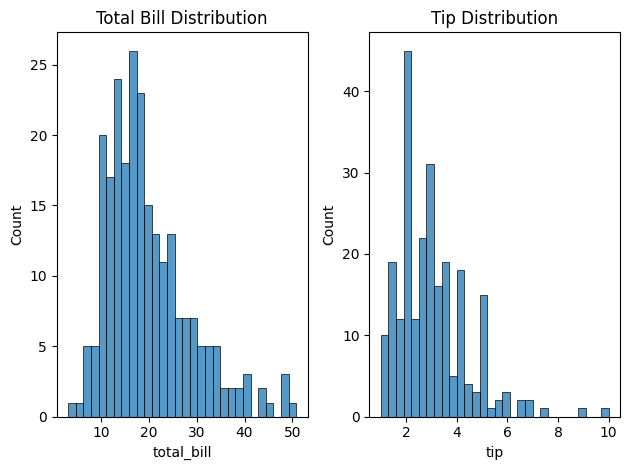

In [3]:
# YOUR CODE HERE
# total_bill histogram
plt.subplot(1, 2, 1)
sns.histplot(data=tips_df, x="total_bill", bins=30)
plt.title("Total Bill Distribution")

# tip histogram
plt.subplot(1, 2, 2)
sns.histplot(data=tips_df, x="tip", bins=30)
plt.title("Tip Distribution")

plt.tight_layout()
plt.show()


`.describe()` fonksiyonunu kullanarak elindeki değişkenlerin bir özetini çıkarabilir, `quartile`ların durumuna bakabilirsin.

In [4]:
# YOUR CODE HERE
tips_df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
# YOUR CODE HERE
tips_df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Quartile yorumlama (özellikle önemli kısım)

Örneğin total_bill için:

Q1 → verilerin %25’i bu değerin altında
Q2 (median) → ortadaki değer
Q3 → verilerin %75’i bu değerin altında

👉 Eğer mean > median ise genelde sağa çarpıklık (right-skew) vardır.
👉 total_bill ve tip genelde hafif sağa çarpık çıkar.

Şimdi bu sayıları oluşturacağın boxplot grafiği ile karşılaştırabilirsin.

💡 Seaborn `boxplot` fonksiyonu ile dağılımı görselleştir, parametreleri kullanarak daha iyi bir grafik elde et!

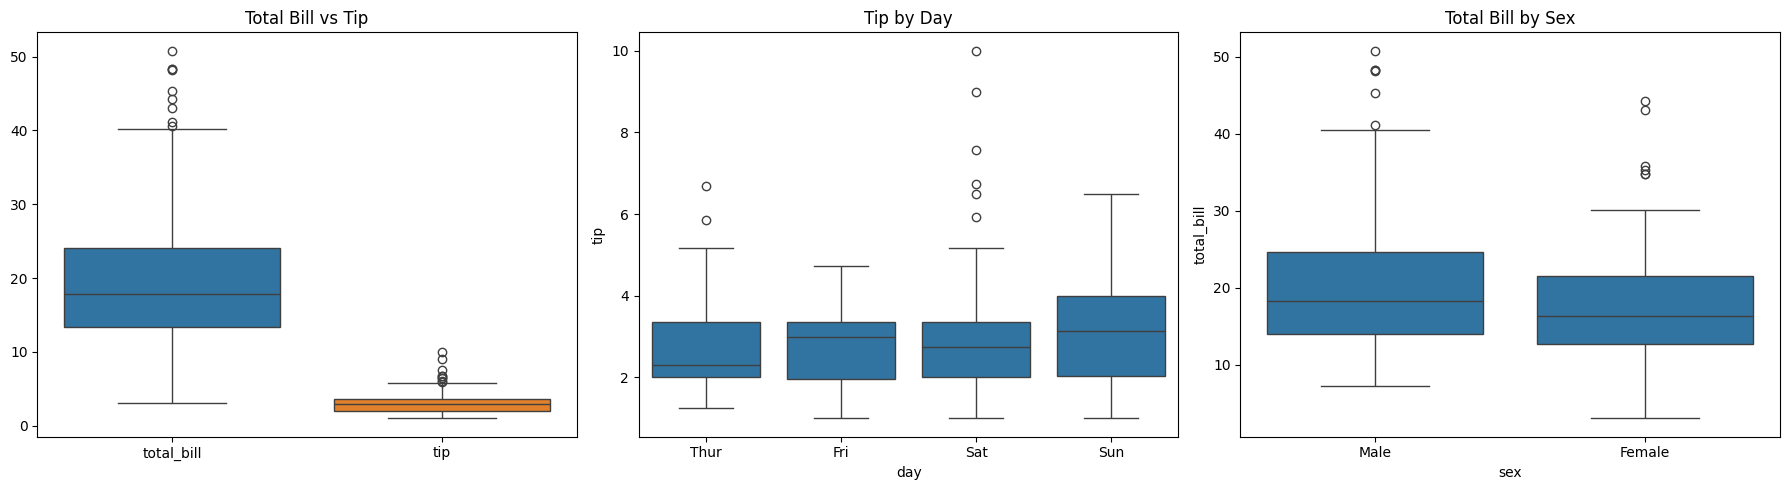

In [6]:
# YOUR CODE HERE


plt.figure(figsize=(18, 5))

# 1) total_bill & tip boxplot (yan yana karşılaştırma)
plt.subplot(1, 3, 1)
sns.boxplot(data=tips_df[["total_bill", "tip"]])
plt.title("Total Bill vs Tip")

# 2) day vs tip
plt.subplot(1, 3, 2)
sns.boxplot(data=tips_df, x="day", y="tip")
plt.title("Tip by Day")

# 3) sex vs total_bill
plt.subplot(1, 3, 3)
sns.boxplot(data=tips_df, x="sex", y="total_bill")
plt.title("Total Bill by Sex")

plt.tight_layout()
plt.show()


### Veri Analizi

Artık diğer özelliklerin `total_bill` ve `tip` üzerindeki etkisini analiz etme zamanı!

`tips` verisindeki `sex`, `smoker`, `day`, `time` ve `size` özelliklerine göre

`total_bill` ve `tip` değişkenlerinin mean, median, standart sapma değerlerinin nasıl değiştiğini hesapla.

Hesapladığın değişkenleri `boxplot`ın `x`, `y` ve `hue` parametrelerini kullanarak oluşturduğun grafiklerle karşılaştır.

##### Cinsiyete Göre Toplam Fatura ve Bahşiş Nasıl Değişiyor #####

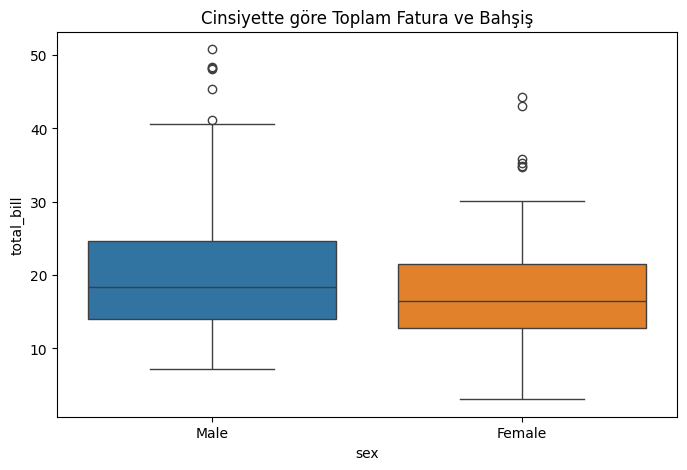

In [7]:
# YOUR CODE HERE
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=tips_df,
    x="sex",
    y="total_bill",
    hue="sex"
)

plt.title("Cinsiyette göre Toplam Fatura ve Bahşiş")
plt.show()


##### Sigara Kullanımına Göre Toplam Fatura ve Bahşiş Nasıl Değişiyor #####

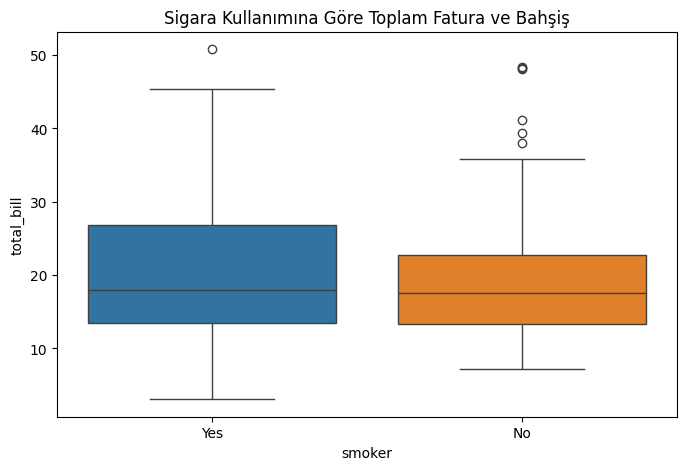

In [8]:
# YOUR CODE HERE
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=tips_df,
    x="smoker",
    y="total_bill",
    hue="smoker"
)

plt.title("Sigara Kullanımına Göre Toplam Fatura ve Bahşiş")
plt.show()

In [9]:
tips_df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

##### Haftanın Gününe Göre Toplam Fatura ve Bahşiş Nasıl Değişiyor #####

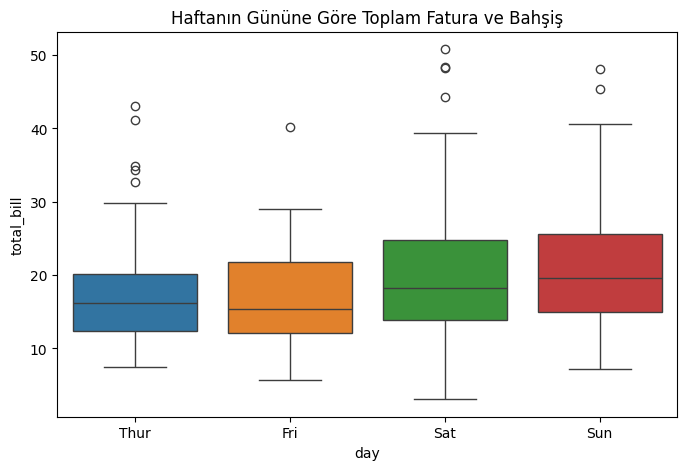

In [10]:
# YOUR CODE HERE
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=tips_df,
    x="day",
    y="total_bill",
    hue="day"
)

plt.title("Haftanın Gününe Göre Toplam Fatura ve Bahşiş")
plt.show()

##### Günün Saatine Göre Toplam Fatura ve Bahşiş Nasıl Değişiyor #####

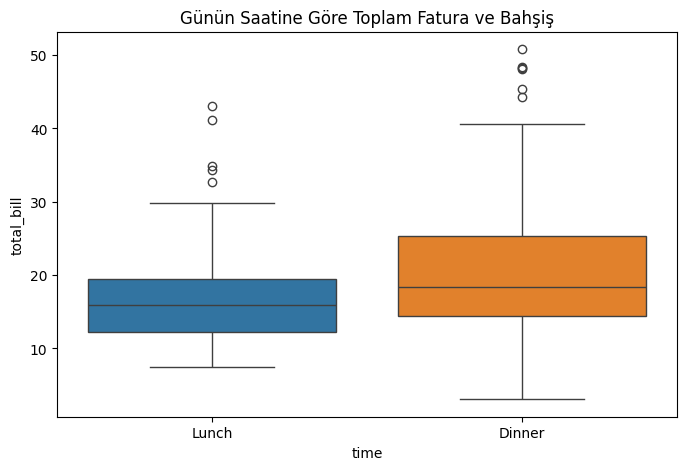

In [11]:
# YOUR CODE HERE
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=tips_df,
    x="time",
    y="total_bill",
    hue="time"
)

plt.title("Günün Saatine Göre Toplam Fatura ve Bahşiş")
plt.show()

##### Kişi Sayısına Göre Toplam Fatura ve Bahşiş Nasıl Değişiyor #####

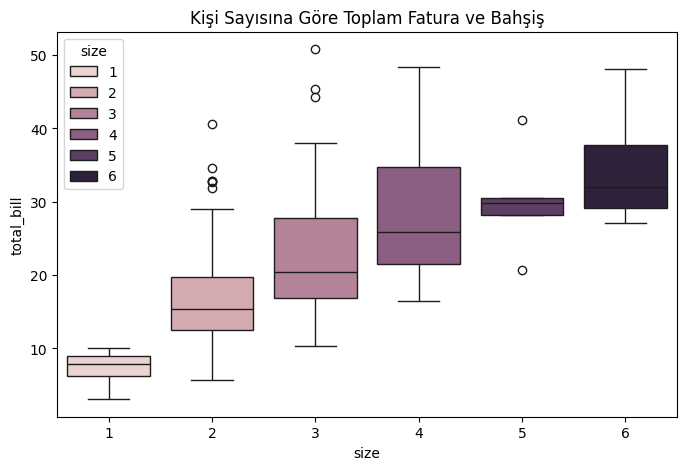

In [12]:
# YOUR CODE HERE
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=tips_df,
    x="size",
    y="total_bill",
    hue="size"
)

plt.title("Kişi Sayısına Göre Toplam Fatura ve Bahşiş")
plt.show()

### İstatistiki Testler

Verisetinden örneklem aldığımız durumlarda örneklemin büyüklüğü verinin resmini gösterebilmesi açısından çok kritiktir!

`sample` fonksiyonunu kullanarak n=10, n=50 ve n=100 olacak şekilde 10ar tane sample oluştur.

Bu sampleların ortalama ve standart sapmalarını hesaplayarak veri setinin tamamında hesapladığınız değerler ile karşılaştır ve yorumla!

💡 Kodu her çalıştırdığınızda farklı sonuçlar görmemek için `random_state` parametresini kullan.

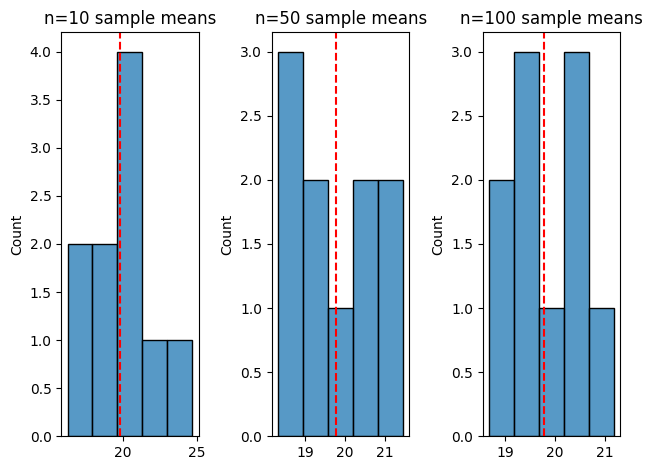

In [13]:
# YOUR CODE HERE
samples_n10 = [tips_df.sample(n=10, random_state=i) for i in range(10)]
samples_n50 = [tips_df.sample(n=50, random_state=i) for i in range(10)]
samples_n100 = [tips_df.sample(n=100, random_state=i) for i in range(10)]

samples_n10_mean = [df["total_bill"].mean() for df in samples_n10]
samples_n10_std  = [df["total_bill"].std() for df in samples_n10]

samples_n50_mean = [df["total_bill"].mean() for df in samples_n50]
samples_n50_std  = [df["total_bill"].std() for df in samples_n50]

samples_n100_mean = [df["total_bill"].mean() for df in samples_n100]
samples_n100_std  = [df["total_bill"].std() for df in samples_n100]

overall_mean = tips_df["total_bill"].mean()
overall_std = tips_df["total_bill"].std()


# n=10
plt.subplot(1, 3, 1)
sns.histplot(samples_n10_mean, bins=5)
plt.axvline(overall_mean, color="red", linestyle="--")
plt.title("n=10 sample means")

# n=50
plt.subplot(1, 3, 2)
sns.histplot(samples_n50_mean, bins=5)
plt.axvline(overall_mean, color="red", linestyle="--")
plt.title("n=50 sample means")

# n=100
plt.subplot(1, 3, 3)
sns.histplot(samples_n100_mean, bins=5)
plt.axvline(overall_mean, color="red", linestyle="--")
plt.title("n=100 sample means")

plt.tight_layout()
plt.show()


##### Hipotez Testi - Örnek Senaryo

Akşam yemek yiyen müşteriler daha çok para harcıyor veya daha çok bahşiş veriyor olabilir mi?

##### H0: Dinner ve Lunch ortalamaları eşittir.

Müşterileri `dinner` ve `lunch` olarak iki gruba ayırdıktan sonra `total_bill` ve `tip` değişkenlerini istatistiki olarak test et!

💡 Bu iki grup için t test uygulabilirsin. `stats` modülü içerisinde `ttest_ind` fonksiyonu bu test için oluşturulmuş.

In [14]:
dinner = tips_df[tips_df["time"] == "Dinner"]
lunch = tips_df[tips_df["time"] == "Lunch"]

stat, p_value = stats.ttest_ind(dinner["total_bill"], lunch["total_bill"], equal_var=False)
print("Toplam fatura için: T Değeri: ", stat, " P Value: ", p_value)

stat, p_value = stats.ttest_ind(dinner["tip"], lunch["tip"], equal_var=False)
print("Bahşiş için: T Değeri: ", stat, " P Value: ", p_value)

Toplam fatura için: T Değeri:  3.122986183296264  P Value:  0.002166573514803894
Bahşiş için: T Değeri:  2.0593266215069774  P Value:  0.04126342245429952


Hesaplamış olduğun `p_value`ları yorumla, P Value değeri 0.05'ten küçük mü?

Yemek saatinin bu değişkenler üzerinde istatistiki olarak anlamlı bir etkisi var mı?

Total_bill, daha güçlü fark (p = 0.002)

Dinner müşterileri genelde daha yüksek hesap öder.
##
Tip
Daha zayıf ama yine anlamlı fark (p ≈ 0.04)

Bahşiş davranışı da değişiyor ama etkisi daha küçük
##
Business insight 

 “Zaman (Dinner vs Lunch) müşteri harcama davranışını etkiliyor”

Dinner → daha yüksek total bill
Dinner → biraz daha yüksek tip

##### Şimdi benzer şekilde diğer özelliklerin de etkisini incele! `P_value`ları hesapla ve değişkenlerin anlamlı bir etkisi olup olmadığını açıkla.
  
##### ⚠️ İkiden fazla grubun olduğunda veya karşılaştıracağın değişkenlerin türü değiştiğinde kullanman gereken istatistiki testler değiştir.
##### Buna göre problemine en uygun istatistiki testi araştır ve verilerine o testi uygula!

In [15]:
# YOUR CODE HERE
#2 grup varsa → t-test
#2’den fazla grup varsa → ANOVA
# Kategorik vs Kategorik -> Chi-square
from scipy import stats

groups = [group["total_bill"].values for name, group in tips_df.groupby("day")]

f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA (day vs total_bill)")
print("F statistic:", f_stat)
print("P value:", p_value)

#p < 0.05 → en az 1 gün farklı
#p ≥ 0.05 → günler arasında fark yok

ANOVA (day vs total_bill)
F statistic: 2.7674794432863363
P value: 0.04245383328952052


/var/folders/32/7brgkn013hjc1zlbmg4kpvfw0000gn/T/ipykernel_78532/2372397157.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["total_bill"].values for name, group in tips_df.groupby("day")]


In [16]:
# YOUR CODE HERE
groups_tip = [group["tip"].values for name, group in tips_df.groupby("day")]

f_stat, p_value = stats.f_oneway(*groups_tip)

print("ANOVA (day vs tip)")
print("F statistic:", f_stat)
print("P value:", p_value)

ANOVA (day vs tip)
F statistic: 1.6723551980998699
P value: 0.17358855530405828


/var/folders/32/7brgkn013hjc1zlbmg4kpvfw0000gn/T/ipykernel_78532/3205438613.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups_tip = [group["tip"].values for name, group in tips_df.groupby("day")]


In [17]:
# YOUR CODE HERE
contingency_table = pd.crosstab(tips_df["sex"], tips_df["smoker"])

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square test")
print("Chi2:", chi2)
print("P value:", p_value)
#p < 0.05 → değişkenler bağımsız değil
#p ≥ 0.05 → bağımsız

Chi-square test
Chi2: 0.0
P value: 1.0
